In [1]:
%load_ext autoreload
%autoreload 2

import os

subj = "Subj1"

match subj:
    case 'Subj1':
        N_STAGES = 9
    case 'Subj2':
        N_STAGES = 8
    case 'Subj3':
        N_STAGES = 10

exp = "exp_ablation"
os.makedirs(f"{subj}/{exp}", exist_ok = True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import typing

import mne
import umap
import tqdm
import numpy
import pandas
import joblib
import itertools
import IPython.display
import sklearn.metrics
import matplotlib.colors
import sklearn.preprocessing
import sklearn.decomposition
import tqdm.contrib.itertools
import matplotlib.pyplot as plt
import sklearn.cross_decomposition

import SDA.topology
import SDA.analytics
import SDA.clustquality
import SDA.stageprocess

from full_flow.AutoEncoder import AutoEncoder

### Data

In [3]:
raw_data = mne.io.read_raw_fif(f"{subj}/src/data_rr_filt-raw.fif").drop_channels(ch_names = [ "A1", "A2" ])
epochs = mne.read_epochs(f"{subj}/src/epochs_filt_rr-epo.fif").drop_channels(ch_names = [ "A1", "A2" ])
if subj == "Subj2": # m8 (artifacts at the end)
    epochs = epochs[:-2]

# epochs.average().plot_joint().savefig(f"{subj}/{exp}/eeg.svg")
data = epochs.get_data(copy = True)

Opening raw data file Subj1/src/data_rr_filt-raw.fif...
    Range : 3500 ... 471000 =      7.000 ...   942.000 secs
Ready.
Reading d:\TopoEEG\Subj1\src\epochs_filt_rr-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
1046 matching events found
No baseline correction applied
0 projection items activated


In [4]:
iv_qsda_scores = pandas.read_csv(f"{subj}/exp_full_flow/IV/iv_qsda_scores.csv")

features = pandas.read_feather(f"{subj}/exp_full_flow/features/features.feather")
best_features = pandas.read_feather(f"{subj}/exp_full_flow/qsda/best_features.feather")

epochs = mne.read_epochs(f"{subj}/src/epochs_filt_rr-epo.fif").drop_channels(ch_names = [ "A1", "A2" ])
if subj == "Subj2": # m8 (artifacts at the end)
    epochs = epochs[:-2]

Reading d:\TopoEEG\Subj1\src\epochs_filt_rr-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
1046 matching events found
No baseline correction applied
0 projection items activated


### Results

In [5]:
def analyze(all_features: pandas.DataFrame, n_components: int, folder: str):
    folder = f"{subj}/{exp}/{folder}"
    if os.path.exists(f"{folder}/stats.svg"):
        return
    os.makedirs(folder, exist_ok = True)

    # Scale features
    all_features = sklearn.preprocessing.StandardScaler().fit_transform(all_features)
    numpy.savetxt(f"{folder}/all_features_shape.txt", all_features.shape)

    # PCA
    pca = sklearn.decomposition.PCA(n_components = n_components, svd_solver = "full", random_state = 42)
    pca_features = pca.fit_transform(all_features)
    numpy.save(f"{folder}/pca_features.npy", pca_features)
    numpy.savetxt(f"{folder}/pca_features_shape.txt", pca_features.shape)
    
    numpy.savetxt(f"{folder}/explained_variance.txt", [ pca.explained_variance_ratio_.sum() ])
    numpy.savetxt(f"{folder}/explained_variance_ratios.txt", pca.explained_variance_ratio_)

    # SDA
    sda = SDA.SDA(n_jobs = -1, scale = False, verbose = False)
    results, df_st_edges = sda.apply(pca_features)
    
    results.to_csv(f"{folder}/results.csv")
    df_st_edges.to_csv(f"{folder}/df_st_edges.csv")

    # Analyze
    best_results = SDA.analytics.best_results(results, key = 'Avg-Silh')
    best_results.to_csv(f"{folder}/best_results.csv")
    
    best_result = SDA.analytics.best_result(results, key = 'Avg-Silh', n_stages = N_STAGES)
    best_result_df = pandas.DataFrame([ best_result ])
    best_result_df.to_csv(f"{folder}/best_result.csv")
    
    best_edges = numpy.array(best_result['St_edges'])
    numpy.savetxt(f"{folder}/best_edges.txt", best_edges, fmt = "%d", newline = ' ')

    stage_timing = SDA.analytics.stage_timing(best_edges, epochs)
    stage_timing.to_csv(f"{folder}/stage_timing.csv")
    
    fig = SDA.analytics.plot_stats(pca_features, epochs, best_result, df_st_edges)
    fig.savefig(f"{folder}/stats.svg")
    plt.close(fig)

In [18]:
for col in ["Source", "Algorithm", "Dimension", "Stat"]:
    for group in tqdm.tqdm(iv_qsda_scores[col].unique()):
        to_remove = iv_qsda_scores[iv_qsda_scores[col] == group]["name"].to_numpy()
        
        features_subset = features[list(set(features.columns) - set(to_remove))]
        try:
            analyze(features_subset, 15, f"topological/{col}/{group}")
        except:
            pass

        best_features_subset = best_features[list(set(best_features.columns) - set(to_remove))]
        try:
            analyze(best_features_subset, 15, f"qsda/{col}/{group}")
        except:
            pass

100%|██████████| 12/12 [00:00<00:00, 17.95it/s]


In [6]:
def SourceFilter(row):
    if row['Source'].startswith('dissim'):
        return 'dissim'
    return row['Source']

def MakeSourceRenamer(epochs: mne.Epochs):
    def SourceRenamer(initial: str) -> str:
        if initial == 'dissim':
            return 'Pearson dissim.'
        if initial == 'overall':
            return 'Overall proc.'
        ind = initial.find('-') + 1
        comp = int(initial[ind:])
        return f'Comp. {epochs.ch_names[comp]}'
    return SourceRenamer

def AlgorithmRenamer(row):
    return {
        'amplitude-betti-1':        'Betti amp., p=1',
        'amplitude-betti-2':        'Betti amp., p=2',

        'amplitude-bottleneck':     'Bottleneck amp.',
        'amplitude-wasserstein-1':  'Wasserstein amp., p=1',
        'amplitude-wasserstein-2':  'Wasserstein amp., p=2',
        
        'amplitude-landscape-1-1':  'Pers. land. amp., p=1',
        'amplitude-landscape-1-2':  'Pers. land. amp., p=1',
        'amplitude-landscape-2-1':  'Pers. land. amp., p=2',
        'amplitude-landscape-2-2':  'Pers. land. amp., p=2',
        
        'amplitude-silhouette-1-1': 'Pers. silh. amp., p=1',
        'amplitude-silhouette-1-2': 'Pers. silh. amp., p=1',
        'amplitude-silhouette-2-1': 'Pers. silh. amp., p=2',
        'amplitude-silhouette-2-2': 'Pers. silh. amp., p=2',

        'bd2':                      'Stats, (b + d) / 2',
        'life':                     'Stats, lifetimes',
        'betti':                    'Stats, Betti curves',
        'landscape':                'Stats, pers. landscape',
        'silhouette-1':             'Stats, lvl 1 pers. silh.',
        'silhouette-2':             'Stats, lvl 2 pers. silh.',
        
        'entropy':                  'Persistence entropy',
        'numberofpoints':           'Number of points',
    }[row]

def DimensionRenamer(row):
    return {
        'all':        'All',
        'dim-1':      'Dimension 1',
        'dim-2':      'Dimension 2',
        'dim-3':      'Dimension 3',
        'dim-4':      'Dimension 4',
        'dim-5':      'Dimension 5',
        'norm-1':     'Amp. norm, p=1',
        'norm-2':     'Amp. norm, p=2',
    }[row]

def StatRenamer(row):
    return {
        'kurtosis':      'Kurtosis',
        'skew':          'Skew',
        'max':           'Maximum',
        'mean':          'Mean',
        'median':        'Median',
        'norm-1':        'Norm with p=1',
        'norm-2':        'Norm with p=2',
        'percentile-25': 'Percentile - 25',
        'percentile-75': 'Percentile - 75',
        'std':           'Standard deviation',
        'sum':           'Sum',
    }[row]

In [35]:
def draw_eeg(src_folder, results_folder, ax, title: str, add_noise: bool = False):
    raw_data = mne.io.read_raw_fif(f"{src_folder}/data_rr_filt-raw.fif", verbose='error')# .drop_channels(ch_names = [ "A1", "A2" ])
    epochs = mne.read_epochs(f"{src_folder}/epochs_filt_rr-epo.fif", verbose='error')
    # raw_data = mne.io.read_raw_fif(f"{src_folder}/data.fif", verbose='error')
    # epochs = mne.read_epochs(f"{src_folder}/epochs.fif", verbose='error')
    
    best_edges = numpy.loadtxt(f"{results_folder}/best_edges.txt").astype(int)
    pca_features = numpy.load(f"{results_folder}/pca_features.npy")
    df_st_edges = pandas.read_csv(f"{results_folder}/df_st_edges.csv")
    best_result = pandas.read_csv(f"{results_folder}/best_result.csv").iloc[0]

    st_edges_list = [ ]
    for st_edges in df_st_edges["St_edges"]:
        st_edges = numpy.fromstring(st_edges.strip('[]'), sep = ' ', dtype = numpy.uint)
        st_edges_list.append(st_edges)
    df_st_edges["St_edges"] = st_edges_list

    ax.set_title(f"{title}. Average Silhouette: {round(best_result['Avg-Silh'], 2)}")
    SDA.analytics.plot_eeg_stages(raw_data, best_edges, epochs, pca_features, df_st_edges, best_result, ax = ax, resolution = 2, add_noise = add_noise)

def ablation(type: str, base_type: str, col: str, group: str):
    topo_edges = numpy.loadtxt(f"{subj}/exp_full_flow/results/{base_type}/best_edges.txt").astype(int)
    ablation_edges = numpy.loadtxt(f"{subj}/exp_ablation/{type}/{col}/{group}/best_edges.txt").astype(int)
    print(SDA.clustquality.cluster_metrics_ground(ablation_edges, topo_edges))
    return 1 - SDA.clustquality.cluster_metrics_ground(ablation_edges, topo_edges)['AMI']

    features = numpy.load(f"{subj}/exp_full_flow/results/{base_type}/pca_features.npy")
    _, topo_labels = SDA.stageprocess.form_stage_bands(topo_edges)
    _, ablation_labels = SDA.stageprocess.form_stage_bands(ablation_edges)

    topo_quality = SDA.clustquality.calc_stage_metr_noground(features, topo_edges).mean().rename(lambda col: f'Avg-{col}').to_dict()
    ablation_quality = SDA.clustquality.calc_stage_metr_noground(features, ablation_edges).mean().rename(lambda col: f'Avg-{col}').to_dict()
    print(col, group, topo_quality['Avg-Silh'] - ablation_quality['Avg-Silh'])
    return max(0, topo_quality['Avg-Silh'] - ablation_quality['Avg-Silh'])


def draw_features(iv_qsda: pandas.DataFrame, group_by: str, renamer: typing.Callable[[str], str], ax, title: str):
    stats = iv_qsda.groupby(by = group_by).mean(numeric_only = True).sort_values(by = 'score').reset_index()
    stats['qsda_ablation'] = [ ablation('topological', 'topological', group_by, value) for value in stats[group_by] ]
    stats[group_by] = stats[group_by].apply(renamer)
    
    stats['score'] = stats['score'] / stats['score'].max()
    stats['IV'] = stats['IV'] / stats['IV'].max()
    # stats['qsda_ablation'] = stats['qsda_ablation'] / stats['qsda_ablation'].max()
    stats.plot.barh(
        x=group_by,
        y=['qsda_ablation', 'IV', 'score'],
        ax=ax,
        color=[(0, 0.5, 0, 0.66), (1, 0, 0, 0.66), (0, 0.3, 1, 0.66)],
        stacked=False,
        width=0.75,
        label=['Ablation', 'IV', 'QSDA']
    )

    ax.set_title(title)
    ax.xaxis.set_label_text('')
    ax.yaxis.set_label_text('')
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc='lower right')

def draw_sources_heatmap(epochs: mne.Epochs, iv_qsda: pandas.DataFrame, agg_by: str, fig, top: float, title: str, template: str):
    iv_qsda['channel_id'] = iv_qsda['Source'].apply(
        lambda source: source[len('channel-'):] if source.startswith('channel-') else None
    )
    iv_qsda = iv_qsda[~iv_qsda["channel_id"].isna()][["channel_id", "score", "IV"]]

    stats = {}
    for _, row in iv_qsda.groupby(by = 'channel_id').mean().reset_index().iterrows():
        channel_name = epochs.ch_names[int(row['channel_id'])]
        stats[channel_name] = row[agg_by]
    svg = SDA.analytics.draw_sources_heatmap(stats, template)
    png = cairosvg.svg2png(bytestring=svg, dpi = 7200, output_width = 720, output_height = 720)
    image = PIL.Image.open(io.BytesIO(png))
    
    text = mob.TextArea(title, textprops={"fontsize": 30})
    img = mob.OffsetImage(image)
    packed_content = mob.VPacker(children=[text, img], align="center", pad=0, sep=20)
    fig.add_artist(
        mob.AnnotationBbox(packed_content, (0.96, top), xycoords='figure fraction', box_alignment=(1, 1), frameon=False)
    )

def draw(subj, subj_name, exp, template: str):
    src = f"E:/CourseProject/{subj}/src"
    # src = f"E:/CourseProject/{subj}"
    traditional = f"E:/CourseProject/{subj}/{exp}/results/traditional"
    topological = f"E:/CourseProject/{subj}/{exp}/results/topological"
    best_topological = f"E:/CourseProject/{subj}/{exp}/results/best_topological"
    combined = f"E:/CourseProject/{subj}/{exp}/results/combined"
    noise = f"{subj}/exp_noise/results/best_topological"
    
    IV = f"E:/CourseProject/{subj}/{exp}/IV"
    qsda = f"E:/CourseProject/{subj}/{exp}/qsda"

    mosaic = [
        ['traditional',      'source',         '.'     ],
        ['traditional',      'source',         '.'     ],
        ['topological',      'source',         '.'     ],
        ['topological',      'source',         '.'     ],
        ['best_topological', 'source',         '.'     ],
        ['best_topological', 'source',         '.'     ],
        ['combined',         'dimension',      'method'],
        ['combined',         'dimension',      'method'],
        ['noise',            'characteristic', 'method'],
        ['noise',            'characteristic', 'method']
    ]
    fig, axes = plt.subplot_mosaic(mosaic, figsize=(70, 40), width_ratios = (4, 1, 1), layout = 'tight')
    fig.suptitle(f"Subject {subj_name}", fontsize = 36, fontweight = 'bold')
    
    draw_eeg(src, traditional, axes["traditional"], title = "Traditional features")
    draw_eeg(src, topological, axes["topological"], title = "Topological features")
    draw_eeg(src, best_topological, axes["best_topological"], title = "Topological features (QSDA)")
    draw_eeg(src, combined, axes["combined"], title = "Combined features")
    draw_eeg(src, noise, axes["noise"], title = "Topological features (gaussian noise)", add_noise = True)
    
    iv = pandas.read_csv(f"{IV}/IV.csv")
    qsda = pandas.read_csv(f"{qsda}/scores.csv")
    iv_qsda = qsda.join(iv, lsuffix = "name", rsuffix = "Feature")
    iv_qsda["score"] = iv_qsda["score"] * (iv_qsda["unique_values"] >= 200)
    iv_qsda[["Source", "Algorithm", "Dimension", "Stat"]] = iv_qsda['name'].str.split(' ', expand = True)
    iv_qsda["Source"] = iv_qsda.apply(SourceFilter, axis = 1)
    epochs = mne.read_epochs(f"{src}/epochs_filt_rr-epo.fif", verbose='error')
    if exp == "exp_full_flow":
        epochs = epochs.drop_channels(ch_names = [ "A1", "A2" ])

    draw_features(iv_qsda, 'Source', MakeSourceRenamer(epochs), axes['source'], 'Extraction techniques and brain regions')
    draw_features(iv_qsda, 'Algorithm', AlgorithmRenamer, axes['method'], 'Vectorization methods')
    draw_features(iv_qsda, 'Dimension', DimensionRenamer, axes['dimension'], 'Simplex dimensions')
    draw_features(iv_qsda, 'Stat', StatRenamer, axes['characteristic'], 'Statistical characteristics')

    draw_sources_heatmap(epochs, iv_qsda, 'score', fig, 0.96, 'QSDA scores', template)
    draw_sources_heatmap(epochs, iv_qsda, 'IV', fig, 0.67, 'IV scores', template)
    
    return fig

In [ ]:
draw("Subj1", 1, "exp_full_flow", template = "subj_1_12")

{'AMI': 0.8366831247800725, 'ARI': 0.6664745402018549, 'FMI': 0.7121242288434578}
{'AMI': 0.9873187754232698, 'ARI': 0.9910619100164461, 'FMI': 0.9923215186924674}
{'AMI': 0.9010388777673602, 'ARI': 0.7579720402189676, 'FMI': 0.7915391358047188}
{'AMI': 0.8973017632088517, 'ARI': 0.7539406608856857, 'FMI': 0.7880145831795373}
{'AMI': 0.8962234061920998, 'ARI': 0.7407785599794403, 'FMI': 0.7768291209528273}
{'AMI': 0.9012854056141549, 'ARI': 0.7587750779067252, 'FMI': 0.7923043485637594}
{'AMI': 0.905440212440829, 'ARI': 0.772802918937226, 'FMI': 0.8051614329976136}
{'AMI': 0.8766080235548219, 'ARI': 0.7364044919844475, 'FMI': 0.7732840937183681}
{'AMI': 0.9125913888628319, 'ARI': 0.7643991042288248, 'FMI': 0.7971970260834177}
{'AMI': 0.9643377431189947, 'ARI': 0.9545513667923798, 'FMI': 0.9609649302364994}
{'AMI': 0.8932503866008811, 'ARI': 0.74024006546057, 'FMI': 0.7764276306291409}
{'AMI': 0.9635647161655047, 'ARI': 0.9659619534871209, 'FMI': 0.9707711237046172}
{'AMI': 0.8792372057

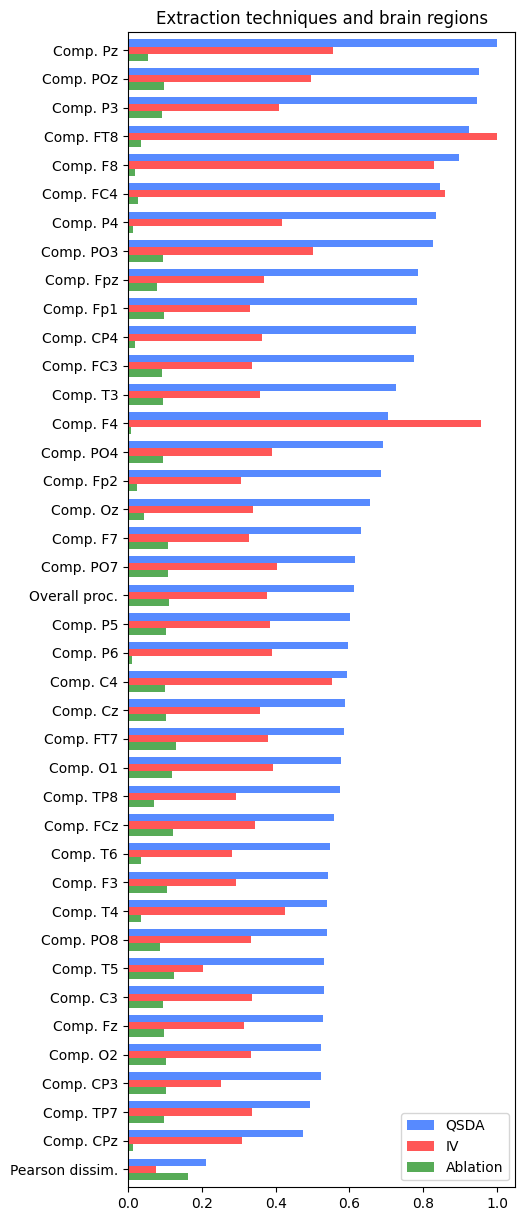

In [36]:
IV = f"E:/CourseProject/{subj}/exp_full_flow/IV"
qsda = f"E:/CourseProject/{subj}/exp_full_flow/qsda"

iv = pandas.read_csv(f"{IV}/IV.csv")
qsda = pandas.read_csv(f"{qsda}/scores.csv")
iv_qsda = qsda.join(iv, lsuffix = "name", rsuffix = "Feature")
iv_qsda["score"] = iv_qsda["score"] * (iv_qsda["unique_values"] >= 200)
iv_qsda[["Source", "Algorithm", "Dimension", "Stat"]] = iv_qsda['name'].str.split(' ', expand = True)
iv_qsda["Source"] = iv_qsda.apply(SourceFilter, axis = 1)

plt.figure(figsize=(5, 15))
draw_features(iv_qsda, 'Source', MakeSourceRenamer(epochs), plt.gca(), 'Extraction techniques and brain regions')